In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [90]:
df=pd.read_csv("23-boston.csv")

In [91]:
df.head()

,0.00632 18.00 2.310 0 0.5380 6.5750 65.20 4.0900 1 296.0 15.30 396.90 4.98 24.00
0,0.02731 0.00 7.070 0 0.4690 6.4210 78...
1,0.02729 0.00 7.070 0 0.4690 7.1850 61...
2,0.03237 0.00 2.180 0 0.4580 6.9980 45...
3,0.06905 0.00 2.180 0 0.4580 7.1470 54...
4,0.02985 0.00 2.180 0 0.4580 6.4300 58...


In [92]:
#datayı alırkan direkt datanın kolonlarını kendi tanımladığımız değerlerle beraber alabiliyoruz
#veielri tek kolon gibi almış ve kolon adları yok


In [93]:
column_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']
df = pd.read_csv("23-boston.csv", header=None, delimiter=r"\s+", names=column_names)
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [94]:
import math

def plot_all_histograms(df,title_prefix=""):
    num_cols=df.select_dtypes(include=[np.number]).columns
    n_cols = 3 #grafiğim kaç kolondan oluşacak
    n_rows = math.ceil(len(num_cols) / n_cols) # kolon sayısı /n_cols'dan bulunan değer yukarı yuvarlanır

    plt.figure(figsize=(5 * n_cols, 4 * n_rows)) #

    for i, col in enumerate(num_cols,1):
        plt.subplot(n_rows, n_cols, i)
        sns.histplot(df[col], kde=True, bins=35) #bins sutun sayısı detaylandırma için yükselt kde de graafikler üzerindeki çizgi
        plt.title(f"{title_prefix}{col}")
        plt.xlabel("")
        plt.ylabel("")

    plt.tight_layout()
    plt.show()

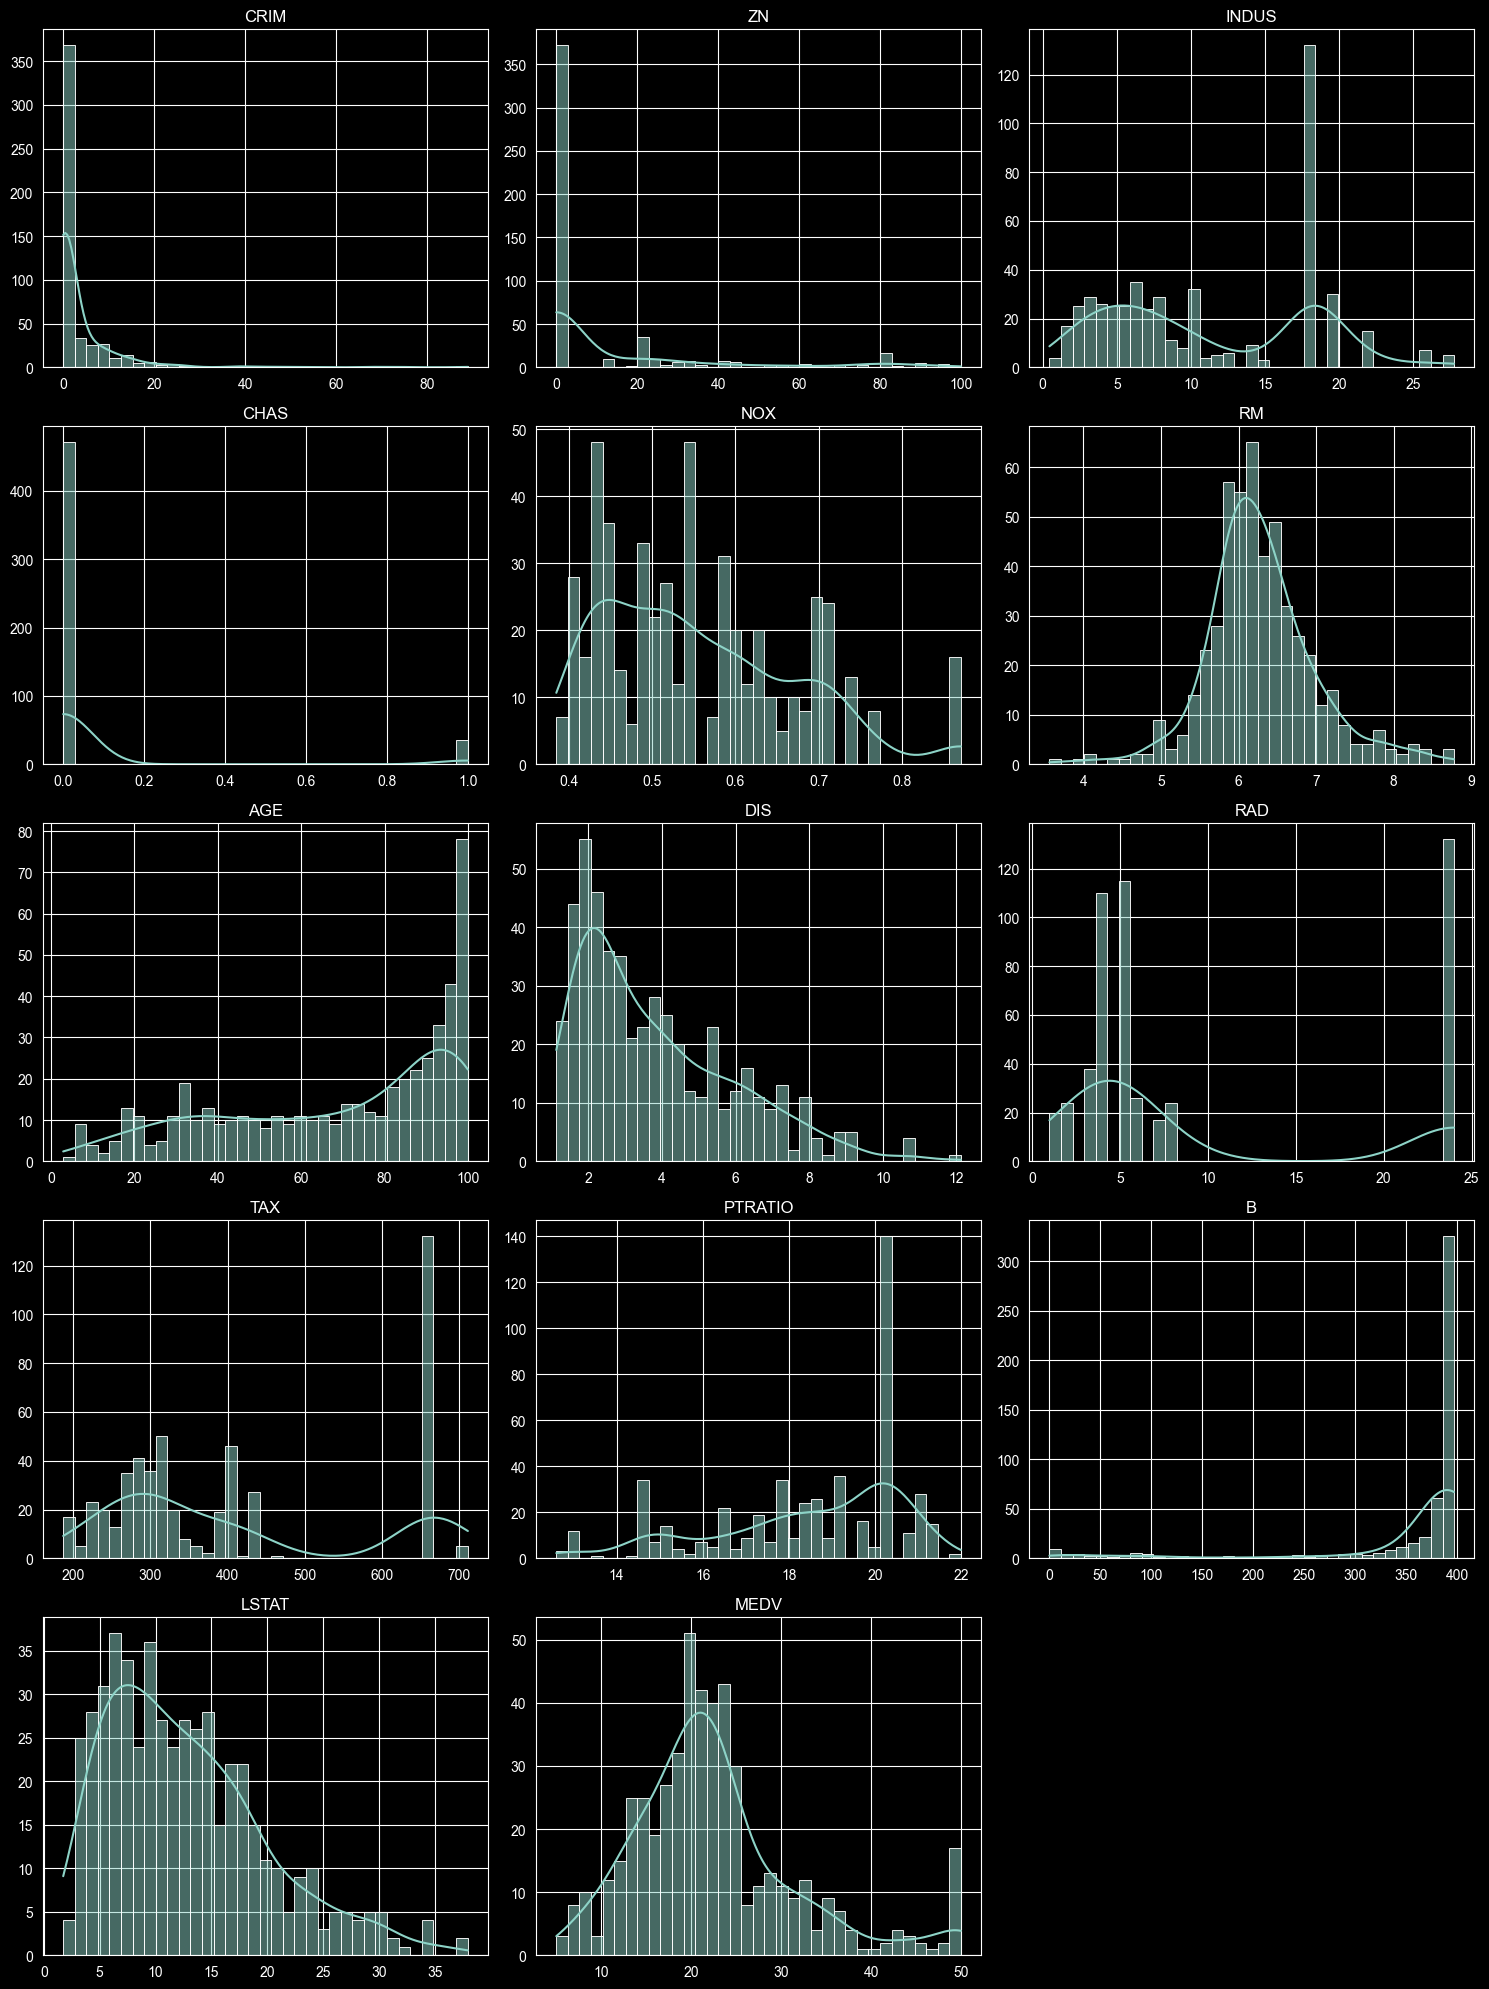

In [95]:
plot_all_histograms(df)

In [96]:
# gördüğümüz bu histogram grafiklerinde sağa veya sola yatkın olanları normal hala getireceğiz peki neden?
# algortmalar normal dağılımda daha iyi sonuç verir outlierlar dengesini bozar

In [97]:
from scipy.stats import skew #grafiğin çarpıklıgını hespalayan kütüphane

In [98]:
skews = df.apply(skew).sort_values(ascending=False)
print(skews)

CRIM       5.207652
CHAS       3.395799
ZN         2.219063
MEDV       1.104811
DIS        1.008779
RAD        1.001833
LSTAT      0.903771
NOX        0.727144
TAX        0.667968
RM         0.402415
INDUS      0.294146
AGE       -0.597186
PTRATIO   -0.799945
B         -2.881798
dtype: float64


In [99]:
X=df.drop("MEDV", axis=1)
y=df["MEDV"]

In [100]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [101]:
from sklearn.preprocessing import PowerTransformer


In [102]:
pt_X=PowerTransformer(method="yeo-johnson")

In [103]:
X_train_transformed=pt_X.fit_transform(X_train)
X_test_transformed=pt_X.transform(X_test)

In [104]:
#numpy dizisini dfe çeviritorum
column_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT',]
X_train_transform_df=pd.DataFrame(X_train_transformed , columns=column_names)
X_test_transform_df=pd.DataFrame(X_test_transformed)

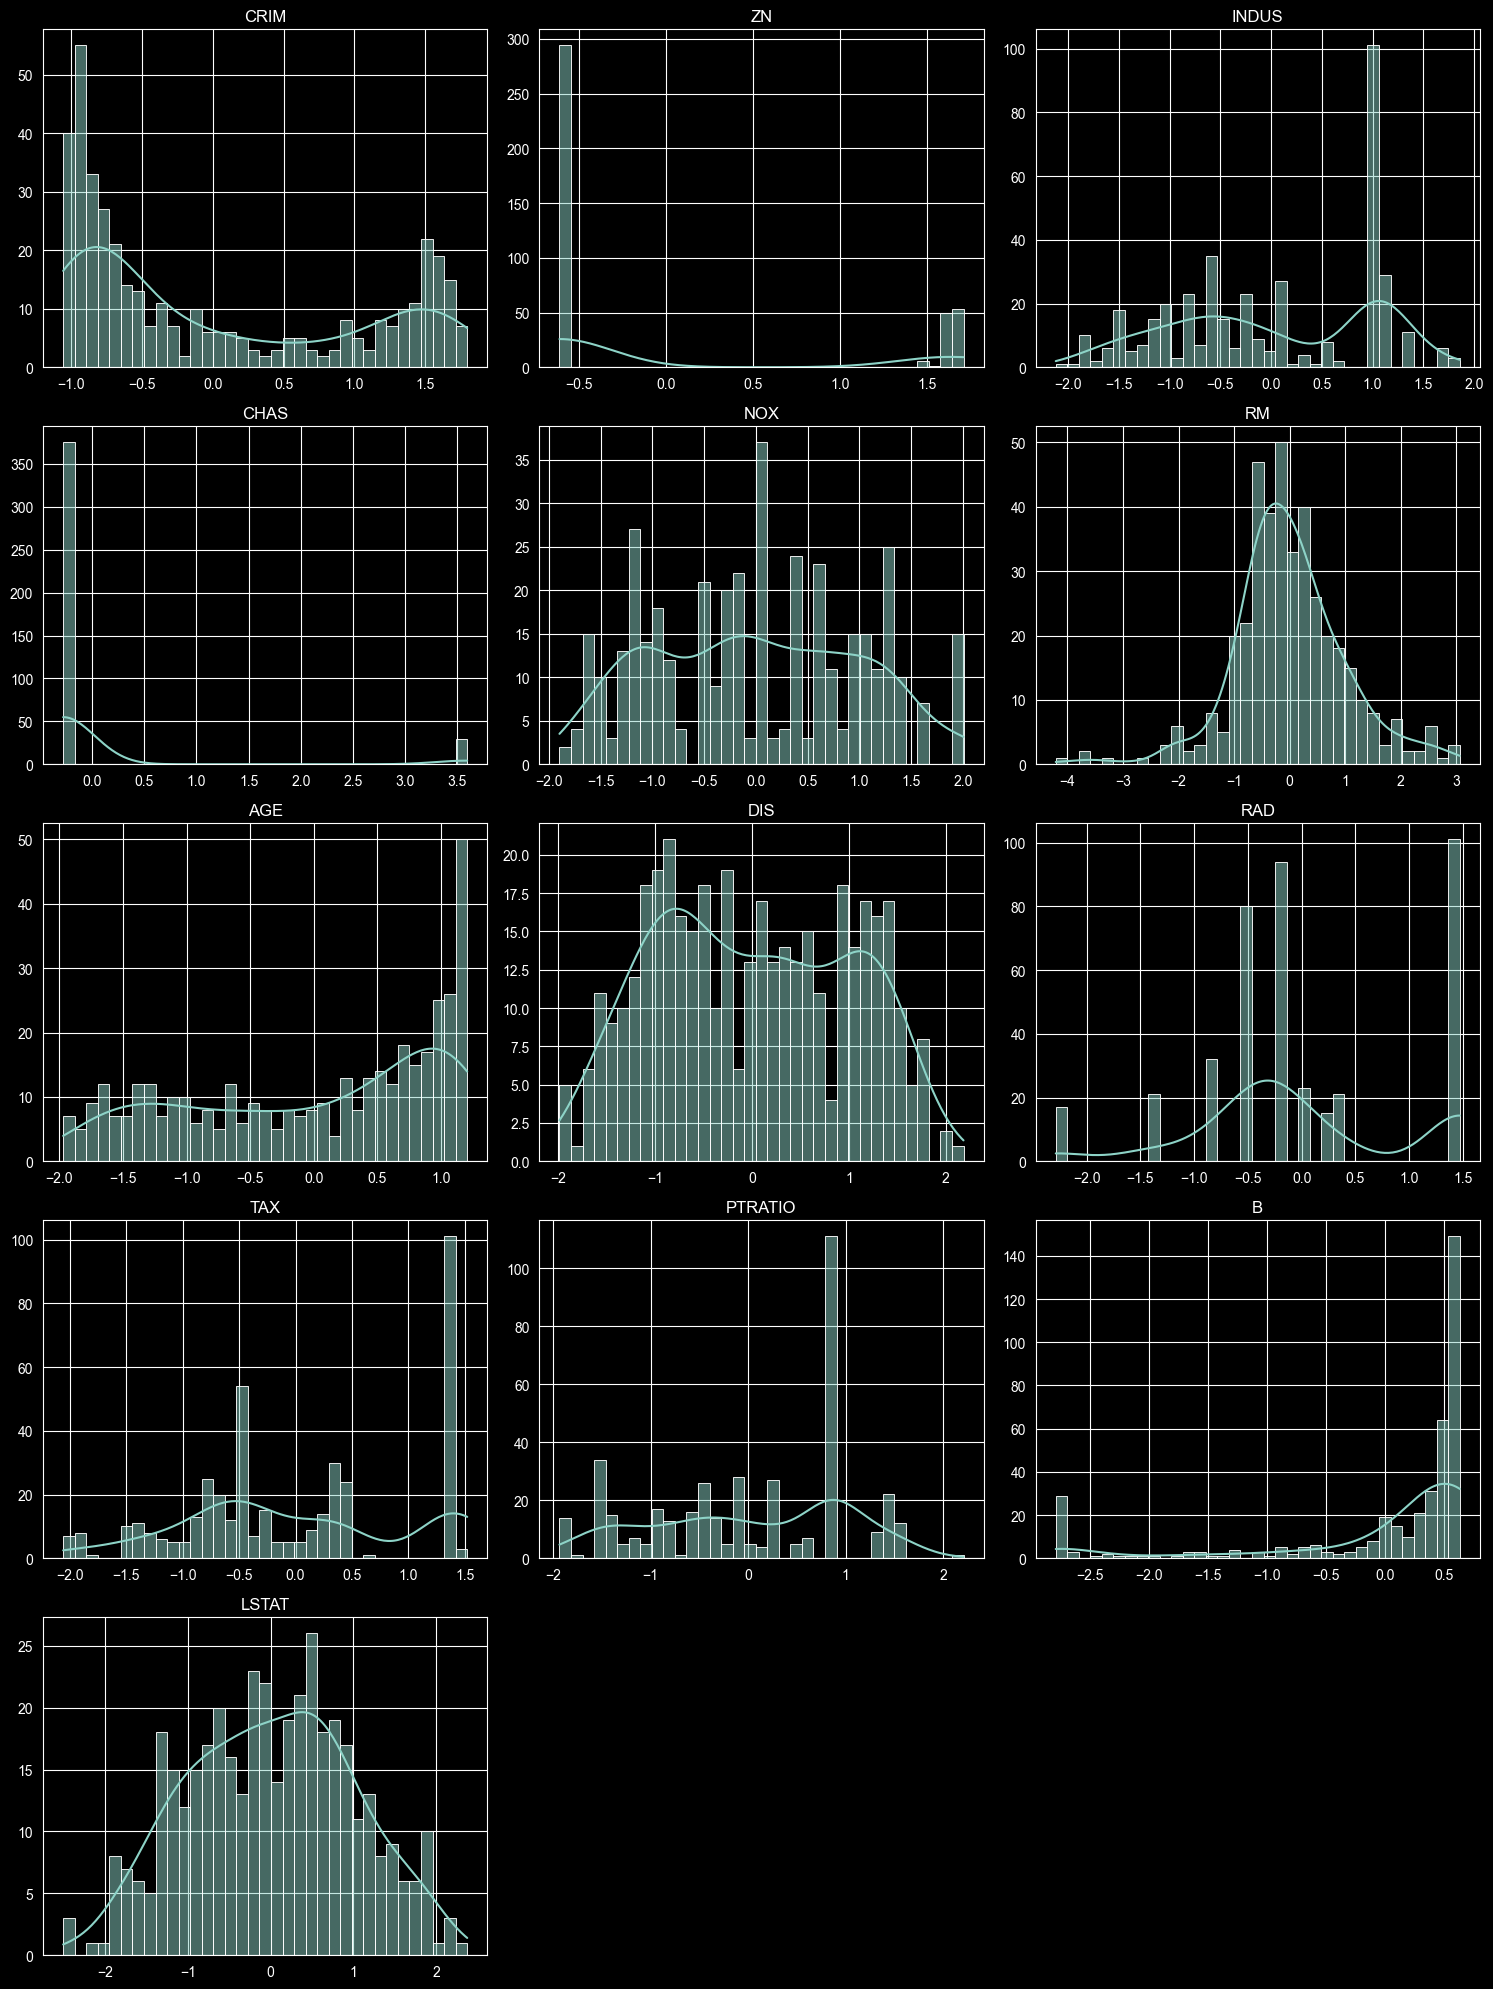

In [105]:
plot_all_histograms(X_train_transform_df)

In [106]:
skews = X_train_transform_df.apply(skew).sort_values(ascending=False)
print(skews)
#İŞE YARAMIŞ

CHAS       3.317886
ZN         1.025869
CRIM       0.587755
NOX        0.099385
TAX        0.074127
DIS        0.073261
RAD        0.059135
RM        -0.000866
LSTAT     -0.014267
INDUS     -0.094228
PTRATIO   -0.208877
AGE       -0.421457
B         -1.902009
dtype: float64


In [107]:
from scipy.stats import boxcox
y_train_transformed, lambda_y = boxcox(y_train) #bu lambda fotmulden gelen bir değer


In [108]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_transformed, y_train_transformed)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [109]:
y_pred_transformed = model.predict(X_test_transformed)
#transform edilmiş fonksiyonun eski haline gelem şekli
def inverse_boxcox(y, lambda_):
    if lambda_ == 0:
        return np.exp(y)
    else:
        return np.power(y * lambda_ + 1, 1 / lambda_)

# original scaling of predictions
y_pred_original = inverse_boxcox(y_pred_transformed, lambda_y)  # burası transform yaptıktan sonra y'yi eski haline getirdiğimiz yer

In [110]:
from sklearn.metrics import mean_squared_error, r2_score
print("R2 Score:", r2_score(y_test, y_pred_original))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_original)))

R2 Score: 0.749924770947926
RMSE: 4.282401501619493


In [111]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("R2 Score:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2 Score: 0.6687594935356347
RMSE: 4.928602182665317


Transform yapıldığı zaman bu şekildeki lineer makina öğrenmesi algoritmaları daha iyi çalışıyor
x ve y de kullanılma durumu değişiyor